In [1]:
import pandas as pd
df_all=pd.read_csv("/Users/kaankeskin/projects/FrequencySliding/data/output/tau_perROI.csv",index_col=0)
print(df_all)

                       0         1         2         3         4         5  \
subject                                                                      
sub-1.results   0.146558  0.048846  0.085489  0.093133  0.463886  0.295246   
sub-10.results  0.082327  0.080025  0.079782  0.082260  0.079061  0.090297   
sub-11.results       NaN  0.081489  0.081203  0.269492       NaN  0.286235   
sub-12.results  0.086344  0.079511       NaN  0.084085       NaN  0.317419   
sub-13.results  0.454147       NaN  0.016508       NaN       NaN  0.098159   
...                  ...       ...       ...       ...       ...       ...   
sub-71.results  0.614633  0.100258  0.106817  0.423392  0.387417  0.364261   
sub-72.results       NaN  0.039514  0.081425  0.085008       NaN  0.082693   
sub-73.results  0.081842  0.077588       NaN  0.077936  0.081009       NaN   
sub-74.results  0.082971  0.082736  0.079743  0.081706  0.077937  0.076852   
sub-75.results  0.076698  0.080296  0.080836  0.078113  0.082494

In [31]:

from pathlib import Path

# --- Paths ---
ctrl_path = Path(r"/Users/kaankeskin/projects/FrequencySliding/data/raw")
ctrl_csv = ctrl_path / "controlregions.csv"
# --- Read CSV ---
# We'll not assume headers; we'll read and rename first two cols defensively.
ctrl_df = pd.read_csv(ctrl_csv)

subject_group_array = ["BP"] * 38 + ["HC"] * 33
region_group_array = ctrl_df["transmodal"]

df_long = df_all.reset_index().melt(id_vars='subject', var_name='region', value_name='value')
df_long['region'] = df_long['region'].astype(int)  # convert column names to integers
df_long['subject_group'] = [subject_group_array[i] for i in df_all.index.get_indexer(df_long['subject'])]
df_long['region_group'] = df_long['region'].map(lambda i: region_group_array[i])


def zscore(s): return (s - s.mean(skipna=True)) / s.std(ddof=0,skipna=True)
df_long["z_value"] = zscore(df_long["value"])

# To be sure 
df_long["subject_group"] = df_long["subject_group"].astype("category")
df_long["subject"] = df_long["subject"].astype("category")
df_long["region_group"] = df_long["region_group"].astype("category")

df_long=df_long.dropna()
print(df_long)

print(df_long["z_value"].describe())
print(df_long["z_value"].isna().sum())
print(df_long["z_value"].nunique())

              subject  region     value subject_group region_group   z_value
0       sub-1.results       0  0.146558            BP            0 -0.143605
1      sub-10.results       0  0.082327            BP            0 -0.491374
3      sub-12.results       0  0.086344            BP            0 -0.469627
4      sub-13.results       0  0.454147            BP            0  1.521791
5      sub-15.results       0  0.085785            BP            0 -0.472652
...               ...     ...       ...           ...          ...       ...
25555  sub-71.results     359  0.078658            HC            1 -0.511243
25556  sub-72.results     359  0.082891            HC            1 -0.488323
25557  sub-73.results     359  0.081633            HC            1 -0.495134
25558  sub-74.results     359  0.086452            HC            1 -0.469040
25559  sub-75.results     359  0.083167            HC            1 -0.486825

[17597 rows x 6 columns]
count    1.759700e+04
mean    -6.460581e-18
std   

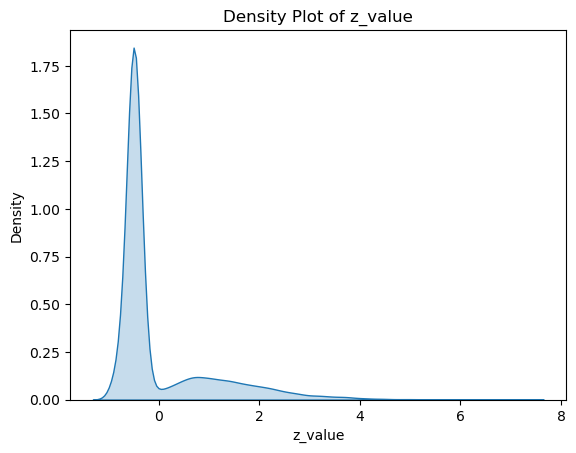

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.kdeplot(data=df_long, x="z_value", fill=True)
plt.title("Density Plot of z_value")
plt.xlabel("z_value")
plt.ylabel("Density")
plt.show()

Sampling: [Intercept, region_group, sigma, subject_group, subject_group:region_group, z_value]


py
0.15.0


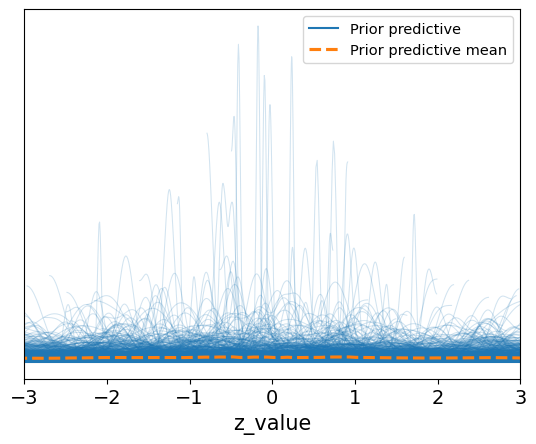

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, subject_group, region_group, subject_group:region_group]


/opt/anaconda3/envs/bayesian/lib/python3.12/site-packages/rich/live.py:231: UserWarning: install "ipywidgets" for 
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/opt/anaconda3/envs/bayesian/lib/python3.12/site-packages/pytensor/scalar/basic.py:3191: RuntimeWarning: overflow encountered in exp
  return np.exp(x)
/opt/anaconda3/envs/bayesian/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/opt/anaconda3/envs/bayesian/lib/python3.12/site-packages/pytensor/scalar/basic.py:3191: RuntimeWarning: overflow encountered in exp
  return np.exp(x)
/opt/anaconda3/envs/bayesian/lib/python3.12/site-packages/pytensor/scalar/basic.py:3191: RuntimeWarning: overflow encountered in exp
  return np.exp(x)
/opt/anaconda3/envs/bayesian/lib/python3.12/site-packages/pytensor/scalar/basic.py:3191: RuntimeWarning: overflow encountered in exp
  return np.exp(x)
/opt/anaconda3/envs/bayesian/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **pass

ValueError: Not enough samples to build a trace.

In [36]:
#import os
#os.environ["PYTENSOR_FLAGS"] = "mode=FAST_RUN,linker=py,cxx="
import pytensor
print(pytensor.config.linker)

import arviz as az
import bambi as bmb
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import xarray as xr
 

priors = {
    "Intercept": bmb.Prior("Normal", mu=0, sigma=0.5),
    "b": bmb.Prior("Normal", mu=0, sigma=0.25),
    "sd": bmb.Prior("Exponential", lam=2),
    "sigma": bmb.Prior("Exponential", lam=2)
}

model = bmb.Model(
    "z_value ~ subject_group * region_group",
    df_long,
    priors=priors,
)
model.build()
prior_predictive = model.prior_predictive(draws=1000)
az.plot_ppc(prior_predictive, group="prior", num_pp_samples=1000)
# Set x-axis limits
plt.xlim(-3, 3)  # Adjust limits based on your data range
plt.show()
posterior = model.fit(draws=2000, tune=2000, chains=4, priors=priors, cores=4, target_accept=0.9, random_seed=123)